# Mini Project 2

By the deadline, please submit the provided Jupyter notebook with all/some required tasks completed and clearly solved. Make sure your code is neat, well-commented, and that all outputs are visible (run all cells before saving). Notebooks with missing tasks or unexecuted cells may receive fewer points. After you submit, you won’t be able to make changes, so double-check your work and be sure to start from the provided template

## Submission rules
As already discussed in class, we will stick to the following rules.
- Use the templates and name your files `NAME_SURNAME.ipynb` (If you have more than one name, just concatenate them). We will compare what you present with that file. 
- Code either not written in Python or not using PyTorch receives a grade of 0. Of course, you can use auxiliary packages when needed (`matplotlib`, `numpy`, ...), but for the learning part, you must use PyTorch.
-  If plagiarism is suspected, TAs and I will thoroughly investigate the situation, and we will summon the student for a face-to-face clarification regarding certain answers they provided. In case of plagiarism, a score reduction will be applied to all the people involved, depending on their level of involvement.
-  If extensive usage of AI tools is detected, we will summon the student for a face-to-face clarification regarding certain answers they provided. If the answers are not adequately supported with in-person answers, we will proceed to apply a penalty to the evaluation, ranging from 10% to 100%.

## Image classification uning a CNN

The CIFAR-10 dataset is a widely used collection of images in the field of computer vision. It consists of 60000 (50000 for the training and 10000 for the test) 32x32 color images across 10 different classes, with each class containing 6,000 images. These classes include common objects such as airplanes, automobiles, cats, and dogs. CIFAR-10 serves as a benchmark for image classification tasks and has been instrumental in developing and evaluating machine learning algorithms for image recognition. 
The task of this assignment is to classify the images

In [1]:
import matplotlib.pyplot as plt
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torch
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from torch.utils.data import Subset, DataLoader
from math import floor


### Task 0 (0 pts)
Understand what's going on in the two cells below. Do the following experiments: 
1. Run the first and the second cell in a row.
2. Run the first cell and two times in a row the second one.

What do you observe? We don't need any answer, but please just keep this phenomenon in mind. 

In [2]:
torch.manual_seed(0)

In [3]:
torch.randint(1, 10 , (1,1))

tensor([[9]])

Now, we'll set a seed that will remain the same for all the code below

### Task 1 (2.5 pts)
Load the [data (You can do it directly in PyTorch)](https://pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html) and take some time to inspect the dataset. Report here at least one image per class and a histogram of the distribution of the images of the training and test set. 

In [4]:
#got this from the pytorch cifar10 tutorial for starting
transform = transforms.Compose( #create a pipeline of transformations to apply to the images
    [transforms.ToTensor(), #convert the image to a tensor, from PIL image or numpy array, from [0,255] to [0,1]
     transforms.Normalize((0.4914, 0.4822, 0.4465), (0.2470, 0.2435, 0.2616))]) #this are mean and std of cifar10, approximation usually use (0.5, 0.5, 0.5) and (0.5, 0.5, 0.5).
#normalizing therefore from [0,1] to [-1,1] approximately.
batch_size = 32 #i ll  tweak this later if needed but is usefull as stuff will be of size [b, c, h, w]

trainset = torchvision.datasets.CIFAR10(root='./data', train=True,
                                        download=True, transform=transform)
trainloader = torch.utils.data.DataLoader(trainset, batch_size=batch_size,
                                          shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR10(root='./data', train=False,
                                       download=True, transform=transform)
testloader = torch.utils.data.DataLoader(testset, batch_size=batch_size,
                                         shuffle=False, num_workers=2) # launches 2s separate Python processes, each of which loads and transforms some of the data.

classes = ('plane', 'car', 'bird', 'cat',
           'deer', 'dog', 'frog', 'horse', 'ship', 'truck')

### **INSPECTING DATA**

In [5]:
# helper to un-normalize and show a single tensor image
mean = (0.4914, 0.4822, 0.4465) #could have computed those but found them online
std = (0.2470, 0.2435, 0.2616)

def unnormalize(img_tensor): #data is normalized for training, to visualize it properly it's needed to unnormalize it
    img = img_tensor.clone()
    for t, m, s in zip(img, mean, std):
        t.mul_(s).add_(m)   # t = t * std + mean
    return img

def show_image(ax, img_tensor, title=None):
    img = unnormalize(img_tensor)
    npimg = img.numpy()
    npimg = np.transpose(npimg, (1,2,0))
    ax.imshow(npimg)
    ax.axis('off')
    if title:
        ax.set_title(title, fontsize=10)

In [6]:
#Collect at least one example per class from the trainset
def one_per_class(dataset, classes):
    """
    Returns a list of (img_tensor, label_idx) with at least one example per class.
    Works with torchvision.datasets.CIFAR10 where images are PIL transformed by `transform`.
    """
    found = {i: None for i in range(len(classes))}
    # dataset[i] returns (image, label)
    for i in range(len(dataset)):
        img, label = dataset[i]
        if found[label] is None:
            found[label] = (img, label)
        if all(v is not None for v in found.values()):
            break
    examples = [found[i] for i in range(len(classes))]
    return examples

examples = one_per_class(trainset, classes)

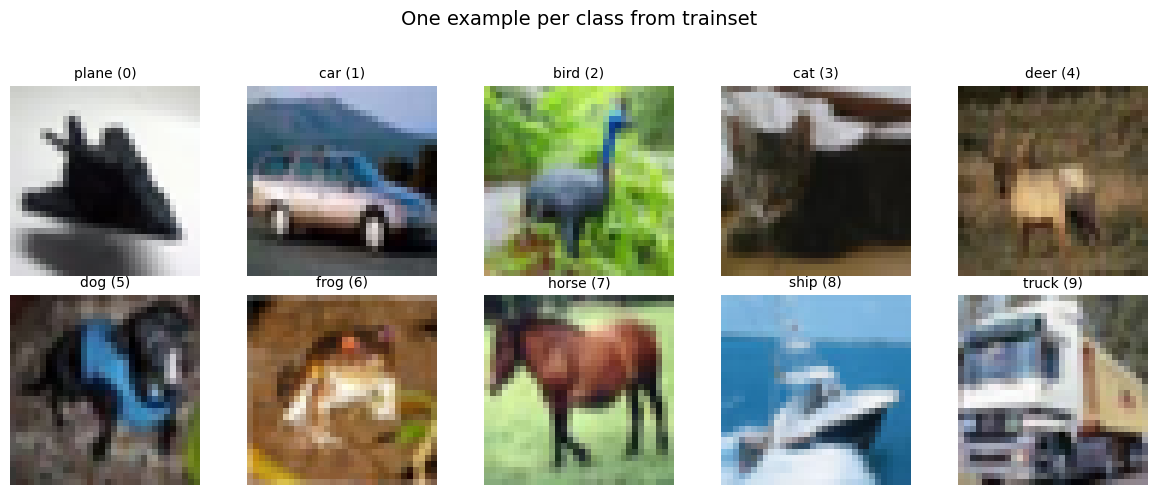

In [7]:
#Plot the examples in a 2x5 grid
fig, axes = plt.subplots(2, 5, figsize=(12,5))
axes = axes.flatten()
for ax, ex in zip(axes, examples):
    img, label = ex
    show_image(ax, img, title=f'{classes[label]} ({label})')
plt.suptitle('One example per class from trainset', fontsize=14)
plt.tight_layout(rect=[0,0,1,0.95])
plt.show()

In [8]:
# Compute class distributions for train and test
def get_targets(dataset):
    return [dataset[i][1] for i in range(len(dataset))]

train_targets = get_targets(trainset)
test_targets = get_targets(testset)

train_counts = np.bincount(train_targets, minlength=len(classes))
test_counts  = np.bincount(test_targets,  minlength=len(classes))

# print numeric counts
print("Train counts per class:")
for i,c in enumerate(train_counts):
    print(f"  {classes[i]:6s}: {c}")
print("Test counts per class:")
for i,c in enumerate(test_counts):
    print(f"  {classes[i]:6s}: {c}")



Train counts per class:
  plane : 5000
  car   : 5000
  bird  : 5000
  cat   : 5000
  deer  : 5000
  dog   : 5000
  frog  : 5000
  horse : 5000
  ship  : 5000
  truck : 5000
Test counts per class:
  plane : 1000
  car   : 1000
  bird  : 1000
  cat   : 1000
  deer  : 1000
  dog   : 1000
  frog  : 1000
  horse : 1000
  ship  : 1000
  truck : 1000


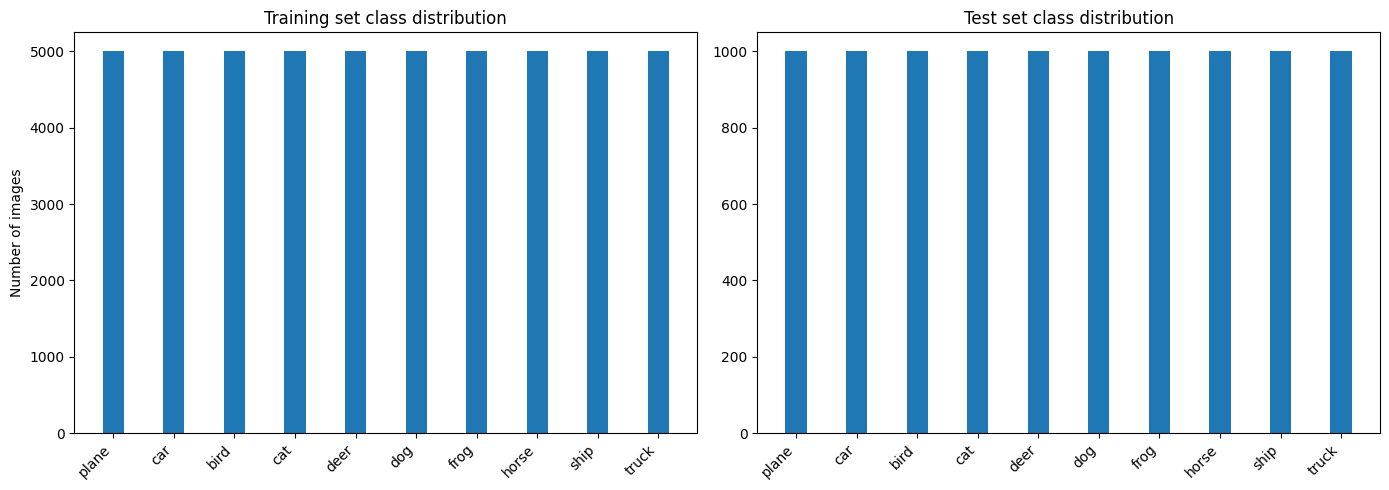

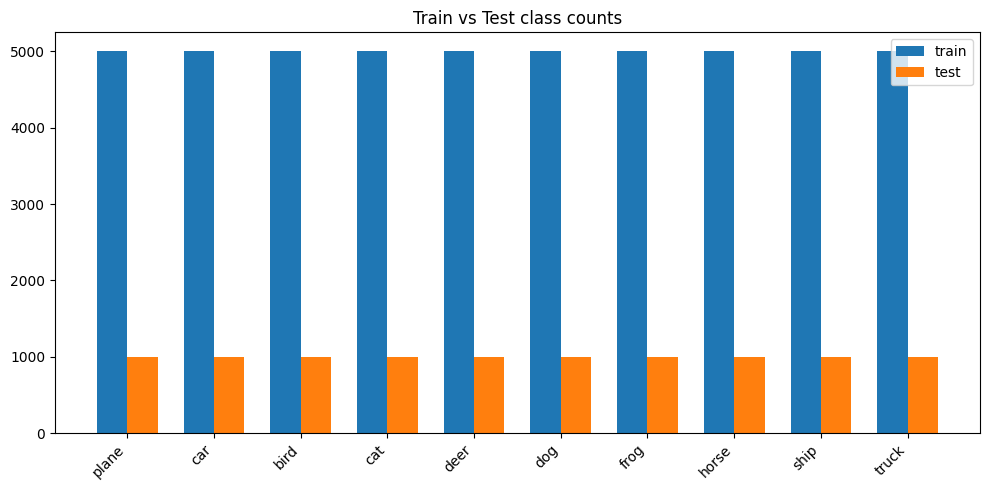

In [9]:
#Plot histograms side-by-side
x = np.arange(len(classes))
width = 0.35

fig, axs = plt.subplots(1,2, figsize=(14,5))
# train
axs[0].bar(x, train_counts, width)
axs[0].set_xticks(x)
axs[0].set_xticklabels(classes, rotation=45, ha='right')
axs[0].set_title('Training set class distribution')
axs[0].set_ylabel('Number of images')
# test
axs[1].bar(x, test_counts, width)
axs[1].set_xticks(x)
axs[1].set_xticklabels(classes, rotation=45, ha='right')
axs[1].set_title('Test set class distribution')
plt.tight_layout()
plt.show()

# 5) Combined histogram for easy comparison (not needed but nice to have)
fig, ax = plt.subplots(figsize=(10,5))
ax.bar(x - width/2, train_counts, width, label='train')
ax.bar(x + width/2, test_counts, width, label='test')
ax.set_xticks(x)
ax.set_xticklabels(classes, rotation=45, ha='right')
ax.set_title('Train vs Test class counts')
ax.legend()
plt.tight_layout()
plt.show()

### Task 2 (2.5 pts)
Are the entries in the correct type for the DL framework in PyTorch? How can you arrive at a suitable format for your training pipeline? Be sure to have understood
- The type of each element of the dataset 
- How we can convert it to a suitable type.
- The dimension of the image as a `torch.Tensor` object
- The meaning of each dimension of the images 

### Task 3 (10 pts)
When you arrive at this question you should have each entry as a `torch.Tensor` of shape (3,32, 32) and clear the meaning of each dimension. A good practice in DL is to work with features having mean 0 and standard deviation equal to 1. Convert the dataset of the images in this format. To do so, you can do it from scratch (not recommended) or use the function [`torchvision.transforms.Normalize`](https://pytorch.org/vision/0.8/transforms.html\#torchvision.transforms.Normalize). If you go for this second option, don't forget that we have already transformed our dataset in the previous point, hence, it could be of help using the function [`transforms.Compose`](https://pytorch.org/vision/0.8/transforms.html\#torchvision.transforms.Compose). You can see an example in the tutorial linked above.

**Note** that the usage of the function is tricky: try to really understand what's going on

### Task 4 (1 pts)
As you might have observed, we only have a train and test set. We need a validation set for hyperparameter tuning. Create a validation set by splitting the test set. 

In [10]:
val_fraction = 0.5   # fraction of original testset to use as validation, can change later
random_state = 42    # reproducible split
n_test = len(testset)                # should be 10000 for CIFAR-10
indices = np.arange(n_test)
labels = [testset[i][1] for i in range(n_test)]  # label for each element in testset

# Stratified split: returns X_train, X_test, y_train, y_test. i used stratify to have same class distribution in val and new test
val_idx, new_test_idx, val_labels, new_test_labels = train_test_split(
    indices, labels,
    test_size=(1.0 - val_fraction),
    stratify=labels,
    random_state=random_state
)

valset = Subset(testset, val_idx) #i used Subset from the utilis package to create the new datasets
new_testset = Subset(testset, new_test_idx)

valloader = DataLoader(valset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)
new_testloader = DataLoader(new_testset, batch_size=batch_size, shuffle=False, num_workers=2, pin_memory=True)

# prints to check everything went well
print(f"Original testset size: {n_test}")
print(f"Validation size: {len(valset)}")
print(f"New test size: {len(new_testset)}")
#check its stratified
val_targets = [val_labels[i] for i in range(len(val_labels))]
new_test_targets = [new_test_labels[i] for i in range(len(new_test_labels))]
print("Val counts per class:", np.bincount(val_targets, minlength=len(classes)))
print("New test counts per class:", np.bincount(new_test_targets, minlength=len(classes)))


Original testset size: 10000
Validation size: 5000
New test size: 5000
Val counts per class: [500 500 500 500 500 500 500 500 500 500]
New test counts per class: [500 500 500 500 500 500 500 500 500 500]


### Task 5 (20 pts)
Starting from the code provided during Lecture 6, define a ConvNet. You can **only** use:

- Convolutional layers  
- Max/Avg Pooling layers  
- Activation Functions  
- Fully connected layers  

Note that the choice `Conv - Pool - Conv` is not mandatory. Have you tried `Conv - Conv - Activ - Pool - Conv - Conv - Activ - Pool - FC`?  
For each convolutional layer you can choose padding and stride. Be prepared on comment on the choices of the dimensions of the layers.

Doing two conv in a row is superflous as they're linear functions and can therefore be combined into one. One could use only activ and conv but Spatial dimensions staying larger means more computation for deeper layers.

Output Size = floor((Input Size - Kernel Size + 2 * Padding) / Stride) + 1 . This formula can be used to compute output size, i always forget it :(

1. Input Images are quite small, and it influences everything else. Even small networks can work well. I used padding =1 because of this , otherwise they would shrink very fast therefore being less informative.
2. Expand to 32 to capture more patterns in the images. Too many would be too slow. kernel size 3.
3. Maxpool half the not-channel dimensions
4. Twice the channels for more features since i have less computing on the other dimensions now.
5. Followed the same approach

In [36]:
def out_dimensions(conv_layer, h_in, w_in):
    '''
    This function computes the output dimension of a Conv2d layer.
    '''
    h_out = floor((h_in + 2 * conv_layer.padding[0] - conv_layer.dilation[0] * (conv_layer.kernel_size[0] - 1) - 1) /
                  conv_layer.stride[0] + 1)
    w_out = floor((w_in + 2 * conv_layer.padding[1] - conv_layer.dilation[1] * (conv_layer.kernel_size[1] - 1) - 1) /
                  conv_layer.stride[1] + 1)
    return h_out, w_out

class CNN(nn.Module):
    def __init__(self):
        super(CNN, self).__init__()

        # Input is CIFAR-10 images: 3 x 32 x 32
        # Use padding=1 on 3x3 convs to keep spatial dims unchanged before pooling
        self.conv1 = nn.Conv2d(3, 32, kernel_size=3, padding=1)   # -> 32 x 32 x 32
        h_out, w_out = out_dimensions(self.conv1, 32, 32)

        self.conv2 = nn.Conv2d(32, 32, kernel_size=3, padding=1)  # -> 32 x 32 x 32
        h_out, w_out = out_dimensions(self.conv2, h_out, w_out)

        self.pool1 = nn.MaxPool2d(2, 2)                           # -> 32 x 16 x 16
        h_out, w_out = h_out // 2, w_out // 2

        self.conv3 = nn.Conv2d(32, 64, kernel_size=3, padding=1)  # -> 64 x 16 x 16
        h_out, w_out = out_dimensions(self.conv3, h_out, w_out)

        self.conv4 = nn.Conv2d(64, 64, kernel_size=3, padding=1)  # -> 64 x 16 x 16
        h_out, w_out = out_dimensions(self.conv4, h_out, w_out)

        self.pool2 = nn.MaxPool2d(2, 2)                           # -> 64 x 8 x 8
        h_out, w_out = h_out // 2, w_out // 2

        # Fully connected head
        flattened = 64 * h_out * w_out
        self.fc1 = nn.Linear(flattened, 256)
        self.fc2 = nn.Linear(256, 10)

        # store final conv feature map dimensions for forward
        self.dimensions_final = (64, h_out, w_out)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.pool1(x)
        
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = self.pool2(x)

        # Flatten and FCs
        n_channels, h, w = self.dimensions_final
        x = x.view(-1, n_channels * h * w)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x


### Task 6 (35 pts)
Implement the training pipeline. Make sure to code the following:

- Print and record the current training loss and accuracy every *n* steps (choose *n*)  
- Print and record the current validation loss and accuracy every *n* steps (choose *n*)  

The validation loss will help you in hyperparameter tuning. Train your model.  
With my choice of hyperparameters, the best test accuracy is above **65%**, hence, a necessary condition to get full marks is to achieve an accuracy on the test set greater or equal to **65%**.

You may want to follow some of these hints (**They are, of course, dependent on the architecture, optimizer, ...**):

- 5 epochs should be enough  
- Batch size = 32 could be a good starting point  
- A learning rate around 0.03 should be a good tradeoff between speed and stability  
- SGD should be a good optimizer  

Be prepared to answer the following questions:
- Why that learning rate? Why not higher/smaller?  
- Number of epochs: Why that number?  
- Some comments on your architecture: why that deep? why not deeper? why not smaller?  

In [37]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [38]:
model = CNN().to(device)

In [39]:
#alradt have 32 size batches
learning_rate = 0.03 #used adviced as it's not too big to overshoot and not to small therefore taking too long to converge
num_epochs = 5 #used adviced as the data is rather simple and without dropout or any form of mitigation there's quite risk of overfitting the ds
#deep cnn without skip connections suffer from vanishing gradient and in this case they would overfit even before that. 
#Smaller could incur in the risk of not being able to catch the features/patterns we're interested with
#and I've started frm the given one which is quite basic and small anyway

In [40]:
criterion = nn.CrossEntropyLoss()       # perfectly balanced dataset
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate) #adviced optimizer maybe i ll try adam 

In [41]:
n_print = 100

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
#for tracking
train_steps = []
val_steps = []
global_step = 0

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0
    
    for i, (inputs, labels) in enumerate(trainloader):
        global_step += 1
        inputs, labels = inputs.to(device), labels.to(device)
        
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()
        
        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
        
        if (i+1) % n_print == 0:
            train_acc = 100. * correct / total
            train_loss = running_loss / n_print
            print(f"Epoch [{epoch+1}/{num_epochs}], Step [{i+1}], "
                  f"Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            train_losses.append(train_loss)
            train_accuracies.append(train_acc)
            train_steps.append(global_step)
            running_loss = 0
            correct = 0
            total = 0
    
    # Validation step 
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in valloader: 
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    
    val_loss /= len(valloader)
    val_acc = 100. * correct / total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_steps.append(global_step)
    print(f"Epoch [{epoch+1}/{num_epochs}] Validation Loss: {val_loss:.4f}, "
          f"Validation Acc: {val_acc:.2f}%")


Epoch [1/5], Step [100], Train Loss: 2.3005, Train Acc: 11.47%
Epoch [1/5], Step [200], Train Loss: 2.2375, Train Acc: 17.62%
Epoch [1/5], Step [300], Train Loss: 2.0219, Train Acc: 25.16%
Epoch [1/5], Step [400], Train Loss: 1.9380, Train Acc: 29.34%
Epoch [1/5], Step [500], Train Loss: 1.8753, Train Acc: 32.34%
Epoch [1/5], Step [600], Train Loss: 1.7721, Train Acc: 36.25%
Epoch [1/5], Step [700], Train Loss: 1.7190, Train Acc: 38.62%
Epoch [1/5], Step [800], Train Loss: 1.6395, Train Acc: 40.53%
Epoch [1/5], Step [900], Train Loss: 1.5945, Train Acc: 42.41%
Epoch [1/5], Step [1000], Train Loss: 1.5708, Train Acc: 44.03%
Epoch [1/5], Step [1100], Train Loss: 1.5261, Train Acc: 44.31%
Epoch [1/5], Step [1200], Train Loss: 1.5176, Train Acc: 43.50%
Epoch [1/5], Step [1300], Train Loss: 1.5120, Train Acc: 45.56%
Epoch [1/5], Step [1400], Train Loss: 1.4569, Train Acc: 47.44%
Epoch [1/5], Step [1500], Train Loss: 1.4612, Train Acc: 48.25%
Epoch [1/5] Validation Loss: 1.5073, Validation A

In [42]:
# Final test evaluation
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        
        test_loss += loss.item()
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_loss /= len(testloader)
test_acc = 100. * test_correct / test_total

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")


Test Loss: 0.9262, Test Accuracy: 69.33%


### Task 7 (4 pts)
Plot the evolution of the training and validation losses on the same graph. On the x-axis, you should preferably use the number of steps. Do you observe signs of overfitting or underfitting? Note that an improperly trained model will also result in a point deduction for the previous exercise.

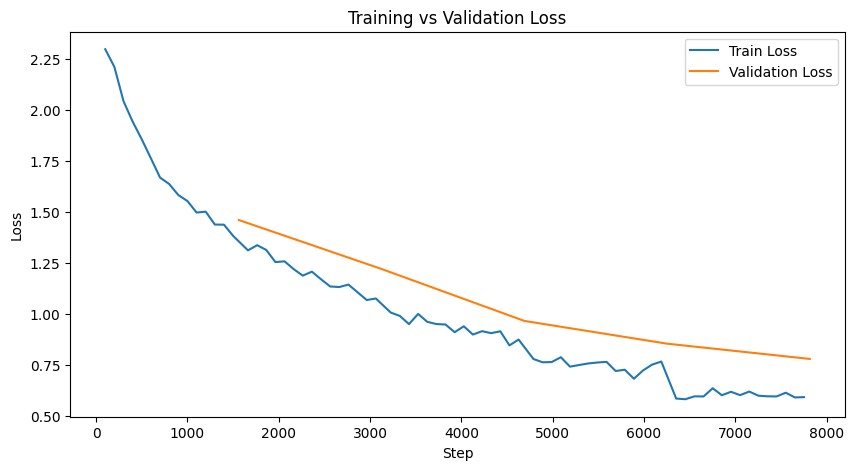

In [17]:
plt.figure(figsize=(10,5))
plt.plot(train_steps, train_losses, label="Train Loss")
plt.plot(val_steps, val_losses, label="Validation Loss")
plt.xlabel("Step")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()

### Task 8 (20 pts)
You may have noticed that it is quite likely to get overfitting in many cases, preventing it from going beyond 65% accuracy.  

Change the architecture as you like and try to increase the accuracy as much as possible. The base architecture must remain a ConvNet.  
Try any idea that comes to your mind but **justify it**.

Some hints:

- Add Dropout (Any other hyperparameter to tune?)  
- Change activation functions ([GeLU](https://arxiv.org/pdf/1606.08415v3.pdf) is known to work well with images)  
- Make your CNN deeper  
- Add some regularization techniques  
- Change the optimizer  
- Data augmentation  
- Batch normalization  
- …  

#### Points distribution:

- Any successful try (test accuracy increase): 6 points  
- Accuracy on test set ≥ 70% : 7 points  
- Accuracy on test set ≥ 72% : 8 points  
- Accuracy on test set ≥ 73% : 9 points  
- …  
- Accuracy on test set ≥ 78% : 15 points  

To get the remaining 5 points you should be able also justify your choices (e.g., “I used Dropout because … and hence I have increased epochs as I noted …”).  

**Note:** Transfer learning is **not allowed** — otherwise you can complete this exercise easily, and it is not useful for educational purposes.

It's not overfitting as I've kept the model quite light to avoid it. There's a gap between validation and test ut it isn't alarming. 

Let's try to tackle the last 6 points then by using both things that prevents overfitting and making it a little larger/more epochs. I'll also use adam and gelu which should work better and they're chosen in modern architecture more often.

i used increasing dropout prob because deeper layers tend to overfit more, i used maxpool with size 2 and slide 2 as it half the dimansion and it's quite a popular choice.

In [21]:
class CNN_Improved(nn.Module):
    def __init__(self):
        super(CNN_Improved, self).__init__()

        # 1st block
        self.conv1 = nn.Conv2d(3, 32, 3, padding=1)      # input: 3x32x32 -> 32x32x32
        self.bn1 = nn.BatchNorm2d(32)                    # 32x32x32
        self.conv2 = nn.Conv2d(32, 32, 3, padding=1)     # 32x32x32 -> 32x32x32
        self.bn2 = nn.BatchNorm2d(32)                    # 32x32x32
        self.pool1 = nn.MaxPool2d(2, 2)                  # 32x32x32 -> 32x16x16
        self.drop1 = nn.Dropout2d(0.2)                   # 32x16x16

        # 2nd block
        self.conv3 = nn.Conv2d(32, 64, 3, padding=1)     # 32x16x16 -> 64x16x16
        self.bn3 = nn.BatchNorm2d(64)                    # 64x16x16
        self.conv4 = nn.Conv2d(64, 64, 3, padding=1)     # 64x16x16 -> 64x16x16
        self.bn4 = nn.BatchNorm2d(64)                    # 64x16x16
        self.pool2 = nn.MaxPool2d(2, 2)                  # 64x16x16 -> 64x8x8
        self.drop2 = nn.Dropout2d(0.3)                   # 64x8x8

        # 3rd block
        self.conv5 = nn.Conv2d(64, 128, 3, padding=1)    # 64x8x8 -> 128x8x8
        self.bn5 = nn.BatchNorm2d(128)                   # 128x8x8
        self.pool3 = nn.MaxPool2d(2, 2)                  # 128x8x8 -> 128x4x4
        self.drop3 = nn.Dropout2d(0.4)                   # 128x4x4

        # Fully connected
        self.fc1 = nn.Linear(128*4*4, 256)               # flatten 128*4*4 = 2048 -> 256
        self.drop_fc = nn.Dropout(0.5)                   # 256
        self.fc2 = nn.Linear(256, 10)                    # 256 -> 10 classes

    def forward(self, x):                                # input: batch x 3x32x32
        x = F.gelu(self.bn1(self.conv1(x)))             # batch x 32x32x32
        x = F.gelu(self.bn2(self.conv2(x)))             # batch x 32x32x32
        x = self.pool1(x)                               # batch x 32x16x16
        x = self.drop1(x)                               # batch x 32x16x16

        x = F.gelu(self.bn3(self.conv3(x)))             # batch x 64x16x16
        x = F.gelu(self.bn4(self.conv4(x)))             # batch x 64x16x16
        x = self.pool2(x)                               # batch x 64x8x8
        x = self.drop2(x)                               # batch x 64x8x8

        x = F.gelu(self.bn5(self.conv5(x)))             # batch x 128x8x8
        x = self.pool3(x)                               # batch x 128x4x4
        x = self.drop3(x)                               # batch x 128x4x4

        x = x.view(-1, 128*4*4)                         # batch x 2048
        x = F.gelu(self.fc1(x))                         # batch x 256
        x = self.drop_fc(x)                             # batch x 256
        x = self.fc2(x)                                 # batch x 10
        return x


In [22]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = CNN_Improved().to(device)

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

num_epochs = 10   # increased due to dropout
n_print = 100

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []
train_steps, val_steps = [], []
global_step = 0


In [23]:
for epoch in range(num_epochs):
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for i, (inputs, labels) in enumerate(trainloader):
        global_step += 1
        inputs, labels = inputs.to(device), labels.to(device)
        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()

        if (i+1) % n_print == 0:
            train_acc = 100.*correct/total
            train_loss = running_loss/n_print
            print(f"Step {global_step}, Train Loss: {train_loss:.4f}, Train Acc: {train_acc:.2f}%")
            train_losses.append(train_loss)
            train_accuracies.append(train_acc)
            train_steps.append(global_step)
            running_loss = 0
            correct = 0
            total = 0

    # Validation
    model.eval()
    val_loss = 0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in valloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_loss += loss.item()
            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()
    val_loss /= len(valloader)
    val_acc = 100.*correct/total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)
    val_steps.append(global_step)
    print(f"Epoch [{epoch+1}] Validation Loss: {val_loss:.4f}, Val Acc: {val_acc:.2f}%")
model.eval()
correct = 0
total = 0
with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        _, predicted = outputs.max(1)
        total += labels.size(0)
        correct += predicted.eq(labels).sum().item()
print(f'Test Accuracy: {100.*correct/total:.2f}%')


Step 100, Train Loss: 2.0854, Train Acc: 22.28%
Step 200, Train Loss: 1.8266, Train Acc: 32.12%
Step 300, Train Loss: 1.7732, Train Acc: 33.69%
Step 400, Train Loss: 1.7150, Train Acc: 36.03%
Step 500, Train Loss: 1.6427, Train Acc: 38.75%
Step 600, Train Loss: 1.6461, Train Acc: 39.19%
Step 700, Train Loss: 1.6568, Train Acc: 39.25%
Step 800, Train Loss: 1.5955, Train Acc: 41.59%
Step 900, Train Loss: 1.5652, Train Acc: 41.78%
Step 1000, Train Loss: 1.5626, Train Acc: 42.94%
Step 1100, Train Loss: 1.5104, Train Acc: 44.66%
Step 1200, Train Loss: 1.5433, Train Acc: 44.16%
Step 1300, Train Loss: 1.4872, Train Acc: 46.12%
Step 1400, Train Loss: 1.4820, Train Acc: 46.72%
Step 1500, Train Loss: 1.4137, Train Acc: 47.59%
Epoch [1] Validation Loss: 1.2157, Val Acc: 56.12%
Step 1663, Train Loss: 1.4032, Train Acc: 48.69%
Step 1763, Train Loss: 1.4114, Train Acc: 48.19%
Step 1863, Train Loss: 1.3865, Train Acc: 49.97%
Step 1963, Train Loss: 1.3607, Train Acc: 51.47%
Step 2063, Train Loss: 1.37

In [33]:
# Final test evaluation
model.eval()
test_loss = 0.0
test_correct = 0
test_total = 0

with torch.no_grad():
    for inputs, labels in testloader:
        inputs, labels = inputs.to(device), labels.to(device)
        outputs = model(inputs)
        loss = criterion(outputs, labels)

        test_loss += loss.item() * labels.size(0)
        _, predicted = outputs.max(1)
        test_total += labels.size(0)
        test_correct += predicted.eq(labels).sum().item()

test_loss = test_loss / test_total
test_acc = 100.0 * test_correct / test_total

print(f"Test Loss: {test_loss:.4f}, Test Accuracy: {test_acc:.2f}%")

Test Loss: 0.6052, Test Accuracy: 79.36%


Got it ;)

I wanted to try to reduce a little the epochs/implement early stopping, possibly in favor of a wider structure as for the last two epochs it learns quite little but 79% is good

### Task 9 (10 pts)

Until now, we asked you to keep the seed fixed.  
Train **the model you defined at Task 5** five times with 5 different seeds (already specified below, **don't change them**), each for the same number of epochs epochs.  
Don't change other hyperparameters. Observe the accuracy of the test set in each case. What can you say?  

In [24]:
batch_size = 32   
lr = 0.03
n_epochs = 5
seeds = list(range(5))
test_accuracies = []


In [30]:
def run_one_seed(n_epochs=5, lr=0.03, n_print=100):
    """
    Train the CNN once using the current RNG state,
    evaluate on validation and test loaders, print per-epoch avg loss and final test accuracy,
    append result to SEED_RESULTS and return test accuracy.
    """
    global SEED_RESULTS

    # create fresh model and optimizer
    model = CNN().to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    criterion = nn.CrossEntropyLoss()

    model.train()
    for epoch in range(n_epochs):
        running_loss = 0.0
        for batch_idx, (inputs, targets) in enumerate(trainloader, start=1):
            inputs, targets = inputs.to(device), targets.to(device)

            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, targets)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()

        # compute an epoch-average loss on trainloader for logging
        model.eval()
        epoch_loss = 0.0
        with torch.no_grad():
            for inputs, targets in trainloader:
                inputs, targets = inputs.to(device), targets.to(device)
                outputs = model(inputs)
                epoch_loss += criterion(outputs, targets).item()
        epoch_avg = epoch_loss / len(trainloader)
        print(f"Epoch {epoch+1}/{n_epochs} done, train avg loss: {epoch_avg:.4f}", flush=True)
        model.train()

    # final validation
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, targets in valloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            val_loss += criterion(outputs, targets).item()
            preds = outputs.argmax(dim=1)
            correct += (preds == targets).sum().item()
            total += targets.size(0)
    val_loss = val_loss / len(valloader)
    val_acc = 100.0 * correct / total
    print(f"Validation Loss: {val_loss:.4f}, Validation Acc: {val_acc:.2f}%", flush=True)

    # final test evaluation
    test_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for inputs, targets in testloader:
            inputs, targets = inputs.to(device), targets.to(device)
            outputs = model(inputs)
            test_loss += criterion(outputs, targets).item()
            preds = outputs.argmax(dim=1)
            test_correct += (preds == targets).sum().item()
            test_total += targets.size(0)
    test_loss = test_loss / len(testloader)
    test_acc = 100.0 * test_correct / test_total
    print(f"Test Loss: {test_loss:.4f}, Test Acc: {test_acc:.2f}%", flush=True)

    # record and return
    SEED_RESULTS.append(test_acc)
    return test_acc


In [31]:
for seed in range(5):
    torch.manual_seed(seed)
    print(f"Testing seed {seed}", flush = True)
    run_one_seed()

Testing seed 0
Epoch 1/5 done, train avg loss: 1.3812
Epoch 2/5 done, train avg loss: 1.0828
Epoch 3/5 done, train avg loss: 0.8090
Epoch 4/5 done, train avg loss: 0.6268
Epoch 5/5 done, train avg loss: 0.4377
Validation Loss: 0.7777, Validation Acc: 73.68%
Test Loss: 0.7858, Test Acc: 73.27%
Testing seed 1
Epoch 1/5 done, train avg loss: 1.3996
Epoch 2/5 done, train avg loss: 1.0843
Epoch 3/5 done, train avg loss: 0.9167
Epoch 4/5 done, train avg loss: 0.6217
Epoch 5/5 done, train avg loss: 0.4893
Validation Loss: 0.7985, Validation Acc: 73.46%
Test Loss: 0.8027, Test Acc: 72.82%
Testing seed 2
Epoch 1/5 done, train avg loss: 1.3795
Epoch 2/5 done, train avg loss: 1.0018
Epoch 3/5 done, train avg loss: 0.9061
Epoch 4/5 done, train avg loss: 0.5793
Epoch 5/5 done, train avg loss: 0.4740
Validation Loss: 0.8130, Validation Acc: 72.12%
Test Loss: 0.8061, Test Acc: 72.54%
Testing seed 3
Epoch 1/5 done, train avg loss: 1.4067
Epoch 2/5 done, train avg loss: 1.0256
Epoch 3/5 done, train avg

Even when keeping hyp the same different runs yelds slighlty different results

## Questions

During the presentation, we may ask questions to ensure you have understood the core concepts of the course. Examples include:
1. Where are the parameters that a CNN learns during training?
2. Why do we use convolutional layers instead of fully connected layers for image data?
3. What is the role of pooling layers? What would happen if we removed them?
4. What is Dropout? Batch Normalizaton? Do you have other regularization tecniques in mind?